# glmm-mcem Tutorial

This notebook walks through fitting a **logistic Generalised Linear Mixed Model (GLMM)** using the `glmm_mcem` package.

## The model

For subject $i = 1, \ldots, n$ with observations $j = 1, \ldots, K_i$:

$$
Y_{ij} \mid u_i \sim \text{Bernoulli}\bigl(\sigma(X_{ij}^\top \beta + u_i)\bigr)
$$
$$
u_i \sim \mathcal{N}(0, V_u)
$$

where $\sigma(\cdot)$ is the logistic sigmoid.  The random intercept $u_i$ captures between-subject heterogeneity that is not explained by the fixed effects $\beta$.

**Parameters to estimate:** the fixed-effect vector $\beta \in \mathbb{R}^p$ and the random-effect variance $V_u > 0$.

## Algorithm overview

The package uses **Monte Carlo Expectation-Maximisation (MCEM)**:

- **E-step** — for each subject, draw samples from the posterior $p(u_i \mid Y_i, \beta, V_u)$ via an independence Metropolis-Hastings sampler whose proposal comes from a Laplace approximation.
- **M-step** — update $\beta$ with a Newton-Raphson step and update $V_u$ as the mean squared sample.

---

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from glmm_mcem import build_dataset, run_mcem, GlmmData, McemResult

## 2. Simulate data

We generate a balanced dataset with:
- $n = 200$ subjects
- $K = 5$ observations per subject
- $p = 3$ predictors (intercept + 2 covariates)
- True $\beta = [-0.5,\ 1.0,\ -0.8]$
- True $V_u = 1.5$

In [2]:
BETA_TRUE = np.array([-0.5, 1.0, -0.8])
VU_TRUE   = 1.5
N         = 200   # subjects
K         = 5     # observations per subject
SEED      = 42

rng     = np.random.default_rng(SEED)
n_obs   = N * K
p       = len(BETA_TRUE)

# Design matrix: intercept column + 2 standard-normal covariates
X = np.column_stack([np.ones(n_obs), rng.standard_normal((n_obs, p - 1))])

# Subject labels: each subject appears exactly K times
subject_ids = np.repeat(np.arange(N), K)

# Draw random intercepts and binary responses
u_true      = rng.normal(0, np.sqrt(VU_TRUE), size=N)
eta         = X @ BETA_TRUE + u_true[subject_ids]
prob        = 1 / (1 + np.exp(-eta))
y           = (rng.uniform(size=n_obs) < prob).astype(float)

print(f"n_obs={n_obs}, n_subjects={N}, response mean={y.mean():.3f}")

n_obs=1000, n_subjects=200, response mean=0.404


## 3. Build a `GlmmData` object

`build_dataset` validates the inputs and pre-computes the per-subject index used throughout the algorithm.

In [3]:
data = build_dataset(y, X, subject_ids)

print(type(data))
print(f"n_obs={data.n_obs}, n_subjects={data.n_subjects}, p={data.p}")
print(f"Rows for subject 0: {data.subject_index[0]}")

<class 'glmm_mcem.data.GlmmData'>
n_obs=1000, n_subjects=200, p=3
Rows for subject 0: [0, 1, 2, 3, 4]


### What does `build_dataset` validate?

It rejects inputs with mismatched shapes, a non-2-D design matrix, or response values outside $\{0, 1\}$:

In [4]:
for bad_y in [np.zeros((5, 2)), np.array([0., 1., 2.])]:
    try:
        build_dataset(bad_y, np.zeros((5, 2)), np.zeros(5))
    except ValueError as e:
        print(f"ValueError: {e}")

ValueError: y must be 1-D, got shape (5, 2)
ValueError: X has 5 rows but y has 3 elements


## 4. Fit the model with `run_mcem`

Key parameters:

| Parameter | Role |
|---|---|
| `initial_variance` | Starting value for $V_u$ |
| `n_iterations` | Maximum MCEM outer iterations |
| `n_mc_samples` | MH draws per subject per iteration (larger → lower MC noise, slower) |
| `burn_in` | MH steps discarded at chain start |
| `step_size` | Newton-Raphson damping factor — reduce below 1 if $V_u$ is large |
| `tol` | Convergence threshold on $\|\Delta\beta\|$ and $|\Delta V_u|/V_u$ |
| `seed` | Fixes the RNG for reproducibility |

In [5]:
result = run_mcem(
    data,
    initial_variance=1.0,
    n_iterations=30,
    n_mc_samples=150,
    burn_in=50,
    step_size=1.0,
    tol=1e-3,
    seed=SEED,
    verbose=True,
)

Cold-start  beta=[-0.423  0.806 -0.577]  Vu=1.0000


  iter   1  beta=[-0.4717  0.9317 -0.6996]  Vu=1.0697  Δbeta=1.82e-01  ΔVu=6.97e-02


  iter   2  beta=[-0.4838  0.9593 -0.7305]  Vu=1.1763  Δbeta=4.32e-02  ΔVu=9.96e-02


  iter   3  beta=[-0.5028  0.9732 -0.7444]  Vu=1.3088  Δbeta=2.73e-02  ΔVu=1.13e-01


  iter   4  beta=[-0.511   0.9867 -0.7587]  Vu=1.4058  Δbeta=2.13e-02  ΔVu=7.41e-02


...

  iter  26  beta=[-0.5639  1.062  -0.8274]  Vu=2.1030  Δbeta=1.01e-02  ΔVu=3.50e-03


  iter  27  beta=[-0.5524  1.0697 -0.8319]  Vu=2.1301  Δbeta=1.45e-02  ΔVu=1.29e-02


  iter  28  beta=[-0.567   1.0581 -0.8305]  Vu=2.1159  Δbeta=1.87e-02  ΔVu=6.66e-03


  iter  29  beta=[-0.5716  1.0601 -0.8246]  Vu=2.0801  Δbeta=7.78e-03  ΔVu=1.69e-02


  iter  30  beta=[-0.5656  1.0657 -0.8262]  Vu=2.1011  Δbeta=8.40e-03  ΔVu=1.01e-02


## 5. Inspect the `McemResult`

In [6]:
print(f"Converged : {result.converged}  (after {result.n_iter} iterations)")
print()
print(f"{'':12} {'True':>8} {'Estimate':>10}")
print("-" * 32)
for j, (b_true, b_est) in enumerate(zip(BETA_TRUE, result.beta)):
    print(f"beta[{j}]      {b_true:>8.4f} {b_est:>10.4f}")
print(f"Vu           {VU_TRUE:>8.4f} {result.Vu:>10.4f}")

Converged : False  (after 30 iterations)

                 True   Estimate
--------------------------------
beta[0]       -0.5000    -0.5656
beta[1]        1.0000     1.0657
beta[2]       -0.8000    -0.8262
Vu             1.5000     2.1011


## 6. Convergence diagnostics

The `history` list records `beta`, `Vu`, and the change norms at every iteration.

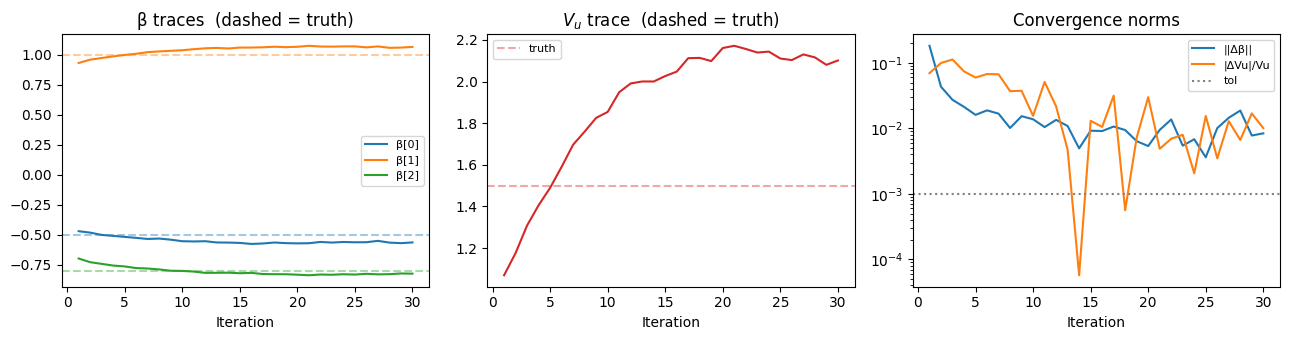

In [7]:
iters      = [h["iteration"]  for h in result.history]
vu_trace   = [h["Vu"]         for h in result.history]
delta_beta = [h["delta_beta"] for h in result.history]
delta_vu   = [h["delta_Vu"]   for h in result.history]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

# --- beta traces ---
ax = axes[0]
beta_traces = np.array([h["beta"] for h in result.history])
for j in range(data.p):
    ax.plot(iters, beta_traces[:, j], label=f"\u03b2[{j}]")
    ax.axhline(BETA_TRUE[j], color=f"C{j}", linestyle="--", alpha=0.4)
ax.set_xlabel("Iteration")
ax.set_title("\u03b2 traces  (dashed = truth)")
ax.legend(fontsize=8)

# --- Vu trace ---
ax = axes[1]
ax.plot(iters, vu_trace, color="C3")
ax.axhline(VU_TRUE, color="C3", linestyle="--", alpha=0.4, label="truth")
ax.set_xlabel("Iteration")
ax.set_title("$V_u$ trace  (dashed = truth)")
ax.legend(fontsize=8)

# --- change norms ---
ax = axes[2]
ax.semilogy(iters, delta_beta, label="||\u0394\u03b2||")
ax.semilogy(iters, delta_vu,   label="|\u0394Vu|/Vu")
ax.axhline(1e-3, color="grey", linestyle=":", label="tol")
ax.set_xlabel("Iteration")
ax.set_title("Convergence norms")
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

## 7. Effect of Monte Carlo sample size

A larger `n_mc_samples` reduces the Monte Carlo variance in each M-step gradient, producing smoother convergence at the cost of runtime.  Here we compare `m = 50` vs `m = 200` on the same dataset.

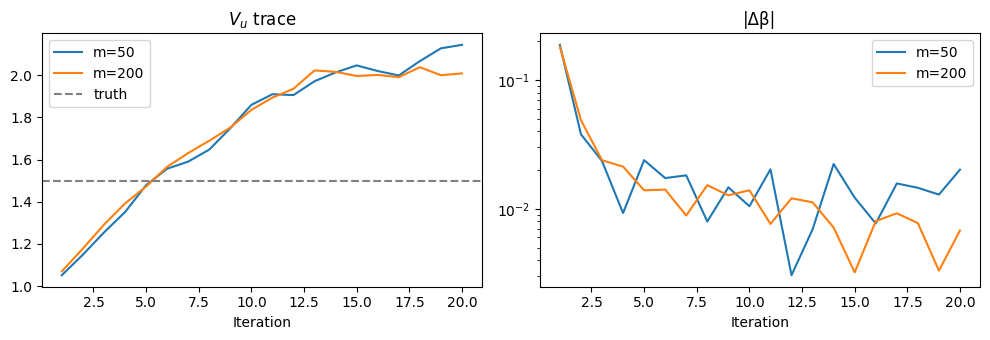

In [8]:
results_by_m = {}
for m in (50, 200):
    results_by_m[m] = run_mcem(
        data,
        n_iterations=20,
        n_mc_samples=m,
        burn_in=20,
        tol=1e-3,
        seed=SEED,
    )

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for m, res in results_by_m.items():
    iters_ = [h["iteration"] for h in res.history]
    vu_tr  = [h["Vu"]        for h in res.history]
    db     = [h["delta_beta"] for h in res.history]
    axes[0].plot(iters_, vu_tr, label=f"m={m}")
    axes[1].semilogy(iters_, db, label=f"m={m}")

axes[0].axhline(VU_TRUE, linestyle="--", color="grey", label="truth")
axes[0].set_title("$V_u$ trace"); axes[0].legend()
axes[1].set_title("|\u0394\u03b2|");  axes[1].legend()
for ax in axes:
    ax.set_xlabel("Iteration")
fig.tight_layout()
plt.show()

## 8. Non-contiguous subject IDs

`build_dataset` re-maps arbitrary subject labels (strings, non-contiguous integers, etc.) to contiguous 0-based integers automatically.

In [9]:
irregular_ids = np.array([10, 10, 50, 50, 99, 99])
data_irr = build_dataset(
    y=np.array([0., 1., 1., 0., 1., 1.]),
    X=np.ones((6, 1)),
    subject_ids=irregular_ids,
)
print("Internal subject IDs:", np.unique(data_irr.subject_ids))
print("Index:", dict(data_irr.subject_index))

Internal subject IDs: [0 1 2]
Index: {0: [0, 1], 1: [2, 3], 2: [4, 5]}


## 9. Using the low-level API

All building blocks are importable individually if you want to customise the algorithm.

```python
from glmm_mcem.likelihoods import log_posterior, sigmoid
from glmm_mcem.laplace     import laplace_approximation
from glmm_mcem.sampler     import sample_random_intercept
from glmm_mcem.estimator   import (
    compute_mc_score_fisher_and_samples,
    newton_raphson_beta_update,
    update_Vu,
)
```

For example, to inspect the Laplace proposal for a single subject:

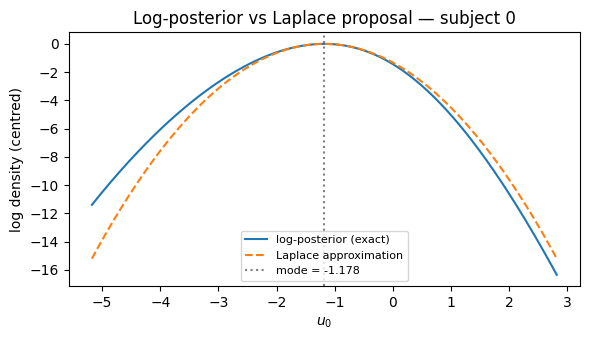

Laplace mode=-1.1775, proposal variance=0.5263


In [10]:
from glmm_mcem.laplace import laplace_approximation
from glmm_mcem.likelihoods import log_posterior

beta_init = np.zeros(data.p)
Vu_init   = 1.0

proposals = laplace_approximation(
    data.y, data.X, data.subject_index,
    beta=beta_init, Vu=Vu_init,
)

subj = 0
mode, var = proposals[subj]
rows = data.subject_index[subj]

u_grid = np.linspace(mode - 4, mode + 4, 300)
log_post = np.array([
    log_posterior(u, data.y[rows], data.X[rows], beta_init, Vu_init)
    for u in u_grid
])
log_laplace = -0.5 * (u_grid - mode)**2 / var + log_post.max()

plt.figure(figsize=(6, 3.5))
plt.plot(u_grid, log_post - log_post.max(),    label="log-posterior (exact)")
plt.plot(u_grid, log_laplace - log_post.max(), label="Laplace approximation", linestyle="--")
plt.axvline(mode, color="grey", linestyle=":", label=f"mode = {mode:.3f}")
plt.xlabel("$u_0$")
plt.ylabel("log density (centred)")
plt.title("Log-posterior vs Laplace proposal \u2014 subject 0")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Laplace mode={mode:.4f}, proposal variance={var:.4f}")

---

## Summary

| Task | Function |
|---|---|
| Prepare data | `build_dataset(y, X, subject_ids)` |
| Fit model | `run_mcem(data, ...)` |
| Read estimates | `result.beta`, `result.Vu` |
| Check convergence | `result.converged`, `result.n_iter` |
| Trace plots | `result.history` (list of dicts) |
| Custom pipelines | Import from `glmm_mcem.likelihoods`, `.laplace`, `.sampler`, `.estimator` |